# 1. Data Cleaning and Preprocessing 

In [1]:
# Core Libraries
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Custom Modules
from calculation import *

# Time Series Analysis
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet

# Machine Learning Models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# Model Selection and Validation
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV, RandomizedSearchCV, cross_val_score

# Evaluation Metrics
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [238]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
path_pattern = "data/climate/climate*.csv"

# Load and preprocess climate data
def load_climate_data(path_pattern):
    files = glob.glob(path_pattern)
    df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    df = df[['Date/Time', 'Year', 'Month', 'Max Temp (°C)', 'Min Temp (°C)', 
             'Heat Deg Days (°C)', 'Cool Deg Days (°C)', 'Total Precip (mm)']]

    rename_map = {
        "Date/Time": "Date",
        "Max Temp (°C)": "Max_Temp",
        "Min Temp (°C)": "Min_Temp",
        "Heat Deg Days (°C)": "Heat_Degree_Days",
        "Cool Deg Days (°C)": "Cool_Degree_Days",
        "Total Precip (mm)": "Total_Precipitation"
    }

    df.rename(columns=rename_map, inplace=True)
    df["Date"] = pd.to_datetime(df["Date"], errors='coerce')
    return df  

# Load the cleaned climate data
climate_df = load_climate_data(path_pattern)

## Particles data set

In [198]:
# File mapping for each pollutant
pollutant_files = {
    "PM2.5": "data/particles/PM25.csv",
    "SO2": "data/particles/SO2.csv",
    "NO2": "data/particles/NO2.csv",
    "NOx": "data/particles/NOx.csv",
    "NO": "data/particles/NO.csv",
    "O3": "data/particles/O3.csv"
}

def process_pollutant_file(name, path):
    df = pd.read_csv(path)
    df["Date"] = pd.to_datetime(df["Date"], format="%d/%m/%Y", errors="coerce")

    # Replace invalid readings
    hourly_cols = [col for col in df.columns if col.startswith("H")]
    df[hourly_cols] = df[hourly_cols].replace({9999: None, -999: None})

    # Compute daily average
    df[name] = df[hourly_cols].mean(axis=1, skipna=True)

    # Clean columns
    drop_cols = hourly_cols + ["Station ID", "Pollutant"]
    df.drop(columns=[col for col in drop_cols if col in df.columns], inplace=True)

    df["ID"] = df.index + 1
    return df[["ID", "Date", name]]

In [200]:
# Process all pollutants
processed_particles = {
    name: process_pollutant_file(name, path)
    for name, path in pollutant_files.items()
}

# Merge all pollutants using ID and Date
from functools import reduce

merged_particles_df = reduce(
    lambda left, right: pd.merge(left, right, on=["ID", "Date"], how="outer"),
    processed_particles.values()
)

# Ensure numeric and round
pollutant_cols = list(pollutant_files.keys())
merged_particles_df[pollutant_cols] = merged_particles_df[pollutant_cols].apply(pd.to_numeric, errors='coerce')
merged_particles_df = merged_particles_df.round(2)

In [202]:
# Compute AQI for selected pollutants
merged_particles_df["PM2.5_AQI"] = merged_particles_df["PM2.5"].apply(calculate_pm25_aqi)
merged_particles_df["NO2_AQI"] = merged_particles_df["NO2"].apply(calculate_no2_aqi)
merged_particles_df["SO2_AQI"] = merged_particles_df["SO2"].apply(calculate_so2_aqi)
merged_particles_df["O3_AQI"]  = merged_particles_df["O3"].apply(calculate_o3_aqi)

# Get max AQI and dominant pollutant
aqi_cols = ["PM2.5_AQI", "NO2_AQI", "SO2_AQI", "O3_AQI"]
merged_particles_df["AQI"] = merged_particles_df[aqi_cols].max(axis=1)
merged_particles_df["Dominant_Pollutant"] = merged_particles_df[aqi_cols].idxmax(axis=1, skipna=True)

C:\Users\ahmed\AppData\Local\Temp\ipykernel_53252\2448961213.py:10: FutureWarning: The behavior of DataFrame.idxmax with all-NA values, or any-NA and skipna=False, is deprecated. In a future version this will raise ValueError
  merged_particles_df["Dominant_Pollutant"] = merged_particles_df[aqi_cols].idxmax(axis=1, skipna=True)


In [204]:
# Count how often each pollutant is dominant
aqi_counts = merged_particles_df["Dominant_Pollutant"].value_counts()
print(aqi_counts)

# Drop intermediate AQI columns
merged_particles_df.drop(columns=aqi_cols, inplace=True)

# Reorder columns for clarity
column_order = ["ID", "Date", "AQI", "PM2.5", "SO2", "NO2", "NOx", "NO", "O3", "Dominant_Pollutant"]
merged_particles_df = merged_particles_df[column_order]

merged_particles_df.head()

Dominant_Pollutant
PM2.5_AQI    1165
O3_AQI        532
SO2_AQI       126
Name: count, dtype: int64


,ID,Date,AQI,PM2.5,SO2,NO2,NOx,NO,O3,Dominant_Pollutant
0,1,2020-01-01,27.958333,6.71,10.69,10.69,13.29,2.61,24.83,PM2.5_AQI
1,2,2020-01-02,30.541667,7.33,13.65,13.65,18.16,4.52,22.00,PM2.5_AQI
2,3,2020-01-03,61.136481,16.92,19.86,19.86,32.57,12.74,13.00,PM2.5_AQI
3,4,2020-01-04,25.166667,6.04,14.99,14.99,23.60,8.65,18.88,PM2.5_AQI
4,5,2020-01-05,23.768519,4.25,9.30,9.30,11.86,2.60,25.67,O3_AQI


# 2. Data Integration and Transformation

In [210]:
# Merge both DataFrames on "Date" using an outer join to retain all records
df = pd.merge(climate_df, merged_particles_df, on="Date", how="inner")

# Ensure that it is still sorted by Date
df.sort_values(by="Date", inplace=True)

In [214]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1824 entries, 3 to 1826
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Date              1824 non-null   object 
 1   ID                1824 non-null   int64  
 2   Year              1824 non-null   int64  
 3   Month             1824 non-null   int64  
 4   Heat_Degree_Days  1824 non-null   float64
 5   Cool_Degree_Days  1824 non-null   float64
 6   PM2.5             1824 non-null   float64
 7   NO2               1824 non-null   float64
 8   NOx               1824 non-null   float64
 9   O3                1824 non-null   float64
 10  AQI               1824 non-null   float64
 11  Mean_Temp         1824 non-null   float64
 12  AQI_Lag1          1824 non-null   float64
 13  AQI_Lag2          1824 non-null   float64
 14  AQI_Lag3          1824 non-null   float64
 15  Season            1824 non-null   object 
dtypes: float64(11), int64(3), object(2)
memory usag

In [51]:
# List of columns in the desired order
new_column_order = [
    "ID", "Date", "Year", "Month", "Max_Temp", "Min_Temp", 
    "Heat_Degree_Days", "Cool_Degree_Days", "Total_Precipitation", 
    "PM2.5", "SO2", "NO2", "NOx", "NO", "O3", "AQI", "Dominant_Pollutant"
]

# Reorder the columns based on the new_column_order list
df = df[new_column_order]

# Check the result
df.head()

,ID,Date,Year,Month,Max_Temp,Min_Temp,Heat_Degree_Days,Cool_Degree_Days,Total_Precipitation,PM2.5,SO2,NO2,NOx,NO,O3,AQI,Dominant_Pollutant
0,1,2020-01-01,2020,1,1.0,-1.2,18.1,0.0,0.2,6.71,10.69,10.69,13.29,2.61,24.83,27.958333,PM2.5_AQI
1,2,2020-01-02,2020,1,6.2,0.9,14.4,0.0,0.0,7.33,13.65,13.65,18.16,4.52,22.00,30.541667,PM2.5_AQI
2,3,2020-01-03,2020,1,7.7,3.6,12.3,0.0,0.0,16.92,19.86,19.86,32.57,12.74,13.00,61.136481,PM2.5_AQI
3,4,2020-01-04,2020,1,3.6,0.3,16.0,0.0,1.5,6.04,14.99,14.99,23.60,8.65,18.88,25.166667,PM2.5_AQI
4,5,2020-01-05,2020,1,1.9,-1.2,17.7,0.0,5.6,4.25,9.30,9.30,11.86,2.60,25.67,23.768519,O3_AQI


# 3. Exploratory Data Analysis

## 1. Initial Exploration:

Start by understanding the basic structure and information about the dataset.

In [56]:
df.info()
#df.isnull().sum() # Few missing values in numerical data
#df.dtypes # All data types formatting are correct
#df.nunique() # Nothing out the common
#df.describe() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1827 entries, 0 to 1826
Data columns (total 17 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   1827 non-null   int64         
 1   Date                 1827 non-null   datetime64[ns]
 2   Year                 1827 non-null   int64         
 3   Month                1827 non-null   int64         
 4   Max_Temp             1815 non-null   float64       
 5   Min_Temp             1815 non-null   float64       
 6   Heat_Degree_Days     1815 non-null   float64       
 7   Cool_Degree_Days     1815 non-null   float64       
 8   Total_Precipitation  1815 non-null   float64       
 9   PM2.5                1810 non-null   float64       
 10  SO2                  1786 non-null   float64       
 11  NO2                  1786 non-null   float64       
 12  NOx                  1786 non-null   float64       
 13  NO                   1786 non-nul

Till now there is no data type formatting issue, all data records are unique with few missing values that will impute.

## 2.Handling Missing Values 

#### 2.1. Visualize Missing Values

Use a heatmap to visually inspect missing values in the dataset.

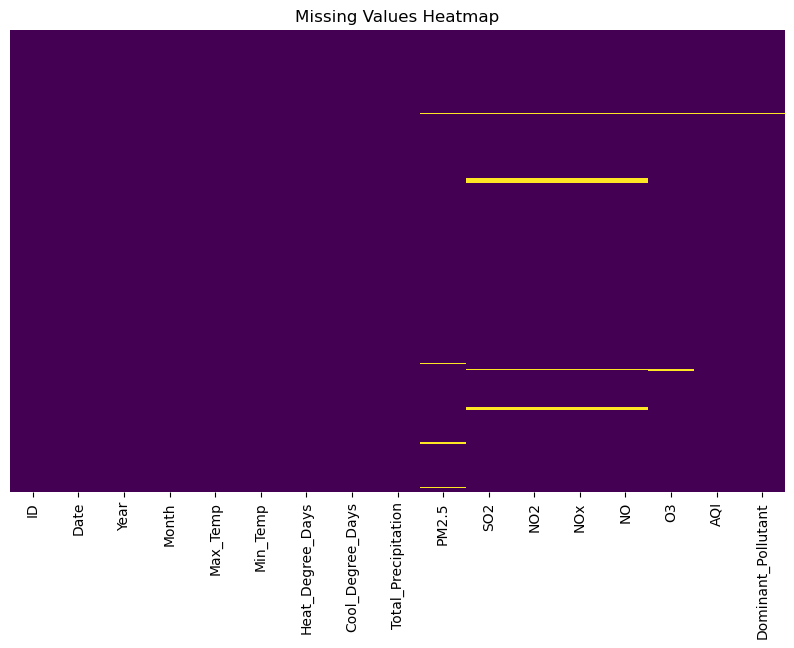

In [62]:
# Visualizing missing values with a heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# Add title and show the plot
plt.title("Missing Values Heatmap")
plt.show()

Visualize scatterplots for each column to detect outliers and make informed decisions on imputation strategy starting with climate data and then particles data.

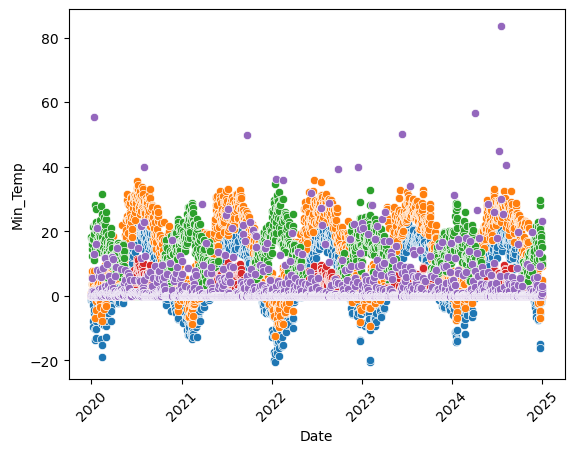

In [65]:
# Visualize Climate Data Outliers
sns.scatterplot(data=df, x='Date', y='Min_Temp')
sns.scatterplot(data=df, x='Date', y='Max_Temp')
sns.scatterplot(data=df, x='Date', y='Heat_Degree_Days')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='Cool_Degree_Days')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='Total_Precipitation')  # Significant Outliers
plt.xticks(rotation=45)
plt.show()

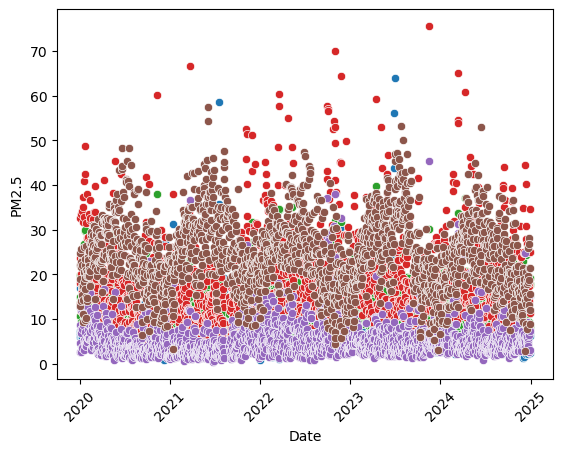

In [67]:
sns.scatterplot(data=df, x='Date', y='PM2.5')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='SO2')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='NO2')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='NOx')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='NO')  # Significant Outliers
sns.scatterplot(data=df, x='Date', y='O3')  # Significant Outliers + Seasonality Pattern
plt.xticks(rotation=45)
plt.show()

### 2.2 Imputing Missing values

To handle missing values, we will use mean imputation for fields where the scatterplot visualization did not show significant outliers, including Min_Temp and Max_Temp. For the remaining fields with significant outliers, we will apply median imputation. These fields include Heat_Degree_Days, Cool_Degree_Days, Total_Precipitation, PM2.5, SO2, NO2, NOx, NO, O3, and AQI.

In [71]:
# Mean imputation for Min_Temp and Max_Temp (no significant outliers)
df['Min_Temp'] = df['Min_Temp'].fillna(df['Min_Temp'].mean())
df['Max_Temp'] = df['Max_Temp'].fillna(df['Max_Temp'].mean())

# Median imputation for Heat_Degree_Days, Cool_Degree_Days, and Total_Precipitation (significant outliers)
df['Heat_Degree_Days'] = df['Heat_Degree_Days'].fillna(df['Heat_Degree_Days'].median())
df['Cool_Degree_Days'] = df['Cool_Degree_Days'].fillna(df['Cool_Degree_Days'].median()) 
df['Total_Precipitation'] = df['Total_Precipitation'].fillna(df['Total_Precipitation'].median())

In [73]:
# Median imputation for all particle data columns (significant outliers)
df['PM2.5'] = df['PM2.5'].fillna(df['PM2.5'].median())
df['SO2'] = df['SO2'].fillna(df['SO2'].median()) 
df['NO2'] = df['NO2'].fillna(df['NO2'].median())
df['NOx'] = df['NOx'].fillna(df['NOx'].median())
df['NO'] = df['NO'].fillna(df['NO'].median()) 
df['O3'] = df['O3'].fillna(df['O3'].median())
df['AQI'] = df['AQI'].fillna(df['AQI'].median())

## 3. Univariate Analysis

### 3.1 Numerical Univariate Analysis

We will analyze the distribution, outliers, and missing values in key variables to inform imputation and further analysis steps. 
Variables Analyzed:
<li>Min_Temp, Max_Temp, Heat_Degree_Days, Cool_Degree_Days, Total_Precipitation.</li>
<li>PM2.5, SO2, NO2, NOx, NO, O3, AQI.</li>

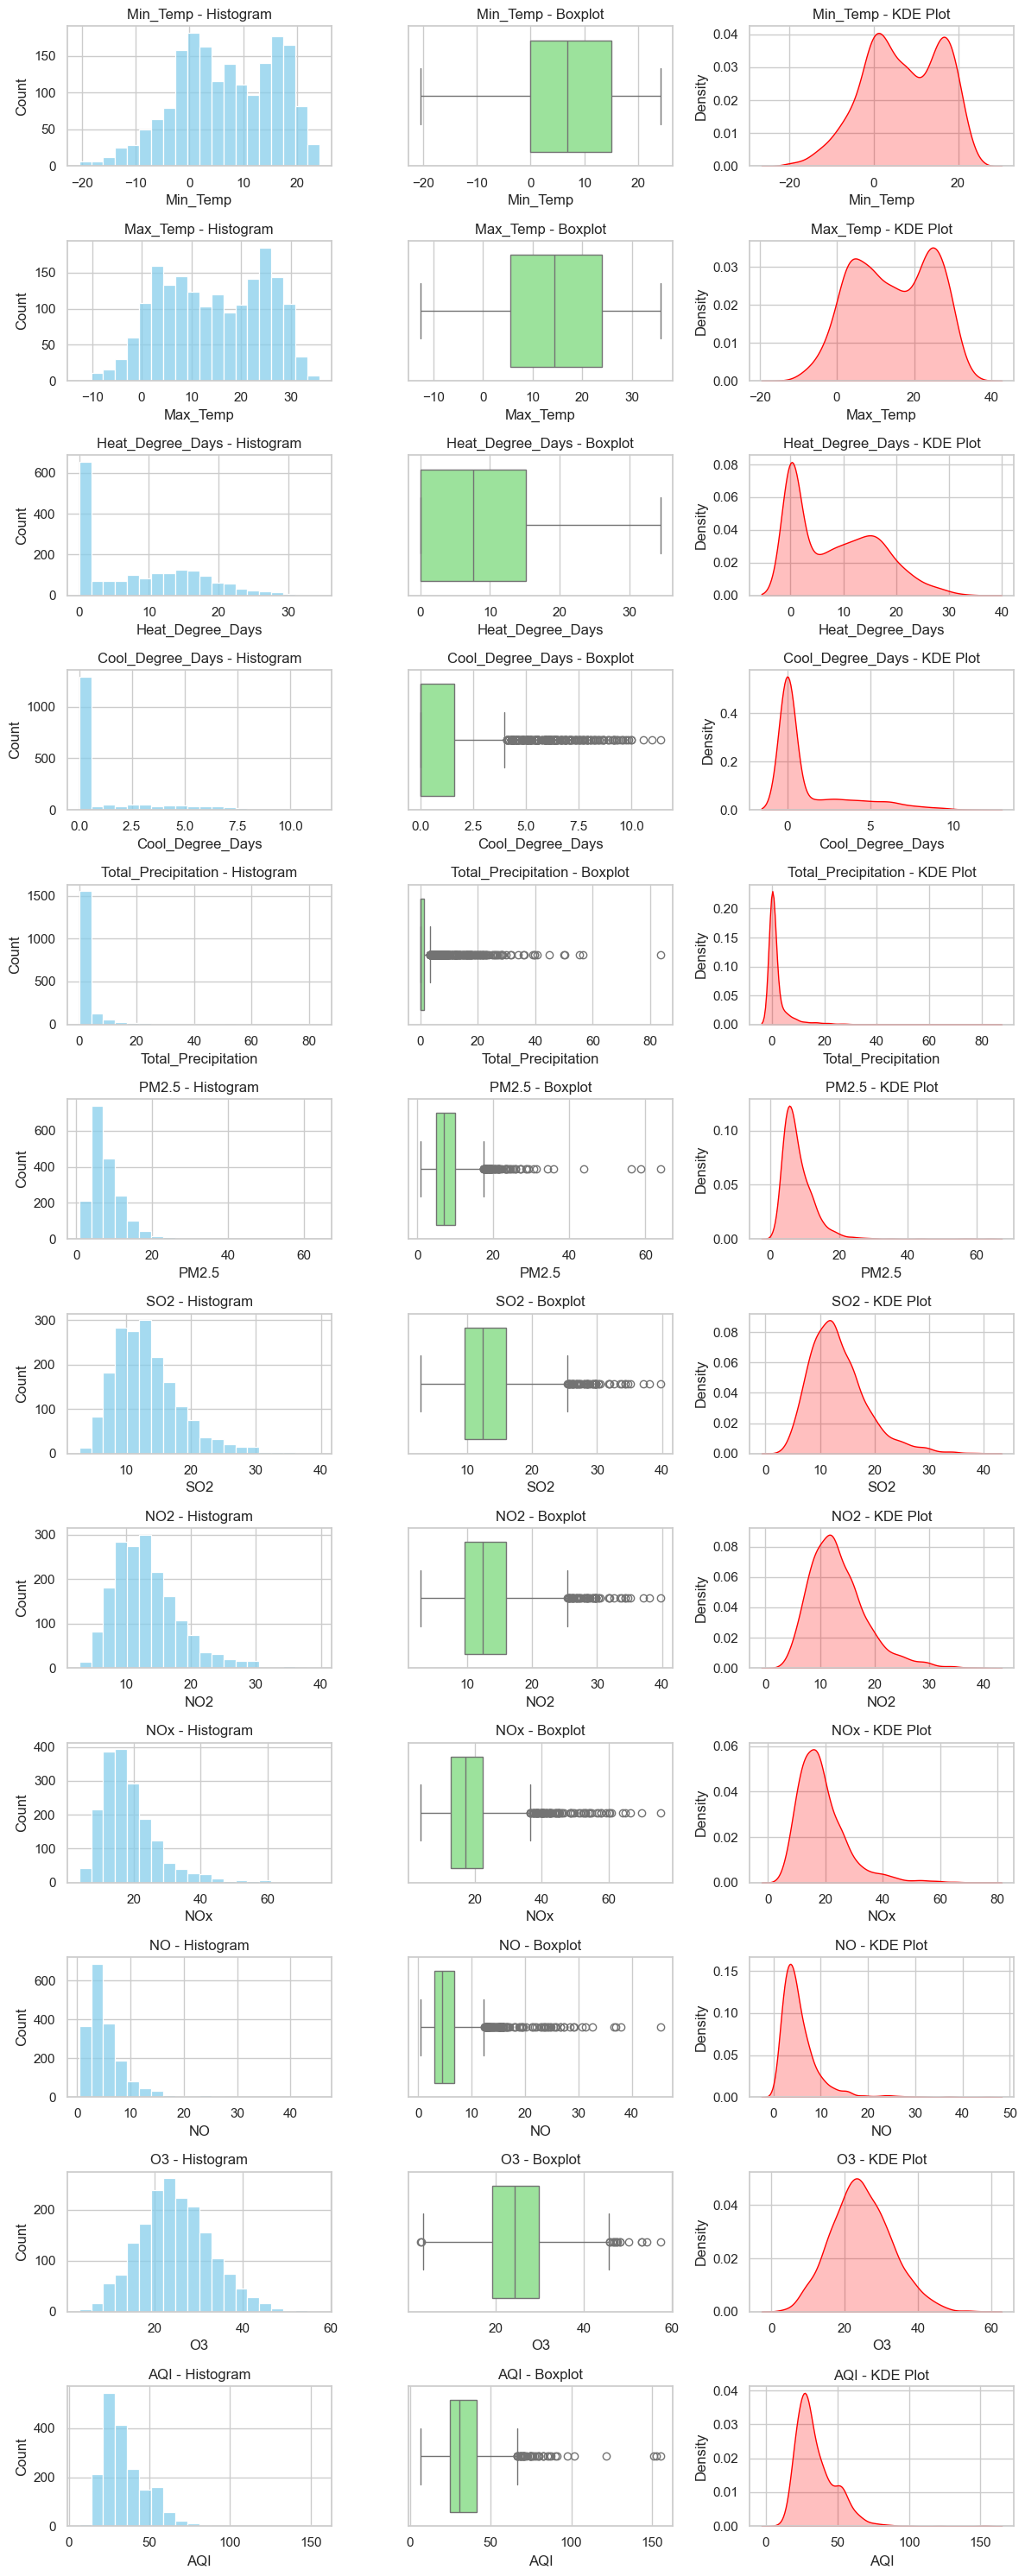

In [78]:
# Set style for the plots
sns.set(style="whitegrid")

# List of columns to analyze univariately
cols_to_analyze = ['Min_Temp', 'Max_Temp', 'Heat_Degree_Days', 'Cool_Degree_Days', 
                   'Total_Precipitation', 'PM2.5', 'SO2', 'NO2', 'NOx', 'NO', 'O3', 'AQI']

# Create a figure with subplots for each variable, adjust the size here
fig, axes = plt.subplots(len(cols_to_analyze), 3, figsize=(12, len(cols_to_analyze)*2.5))  # Adjusted size

# Iterate through each column for the univariate analysis
for i, col in enumerate(cols_to_analyze):
    # Histogram
    sns.histplot(df[col], kde=False, ax=axes[i, 0], bins=20, color='skyblue')
    axes[i, 0].set_title(f'{col} - Histogram')
    
    # Boxplot
    sns.boxplot(x=df[col], ax=axes[i, 1], color='lightgreen')
    axes[i, 1].set_title(f'{col} - Boxplot')
    
    # KDE plot (Kernel Density Estimate)
    sns.kdeplot(df[col], ax=axes[i, 2], color='red', fill=True)
    axes[i, 2].set_title(f'{col} - KDE Plot')

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show()

Based on the Numerical Univariate Analysis, we found that:

<li>Min_Temp: The distribution is slightly right-skewed, indicating that colder temperatures are more frequent, with a few extreme high temperatures.</li>
<li>Max_Temp: This variable is somewhat evenly distributed, suggesting a fairly balanced range of maximum temperatures over time.</li>
<li>The remaining variables, including Heat_Degree_Days, Cool_Degree_Days, and Total_Precipitation, exhibit extreme left skewness, suggesting frequent low values with a few extreme high values.</li>

### 3.2 Categorical Univariate Analysis

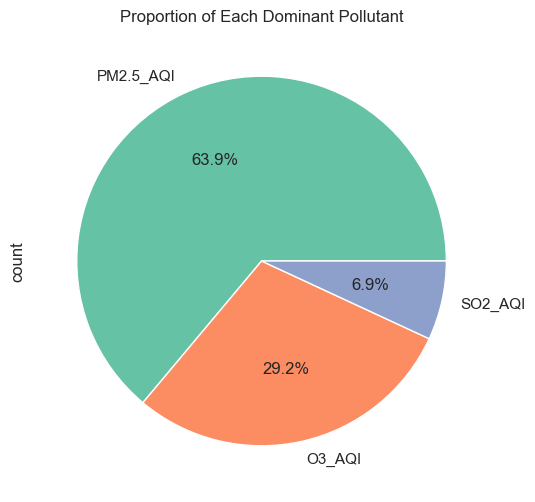

In [81]:
# Count occurrences of each dominant pollutant
pollutant_counts = df["Dominant_Pollutant"].value_counts()

# Plot a pie chart
plt.figure(figsize=(6, 6))
pollutant_counts.plot.pie(autopct="%1.1f%%", colors=sns.color_palette("Set2"))

# Add title
plt.title("Proportion of Each Dominant Pollutant")

# Show plot
plt.show()

Based on the Dominant_Pollutant field derived from AQI formulas, the air particle that most significantly contributes to deteriorating Toronto's air quality is PM2.5, which is the dominant pollutant 63.9% of the time. Following this, O3 contributes 29.2%, while SO2 accounts for 6.9%. NO2 contributes negligibly compared to the other pollutants, showing no presence in the dataset.

## 4. Bivariate Analysis

Bivariate analysis examines the relationships between two variables to identify patterns, dependencies, or potential predictors for AQI. The key objective is to determine which factors significantly influence AQI levels and assess multicollinearity among independent variables.

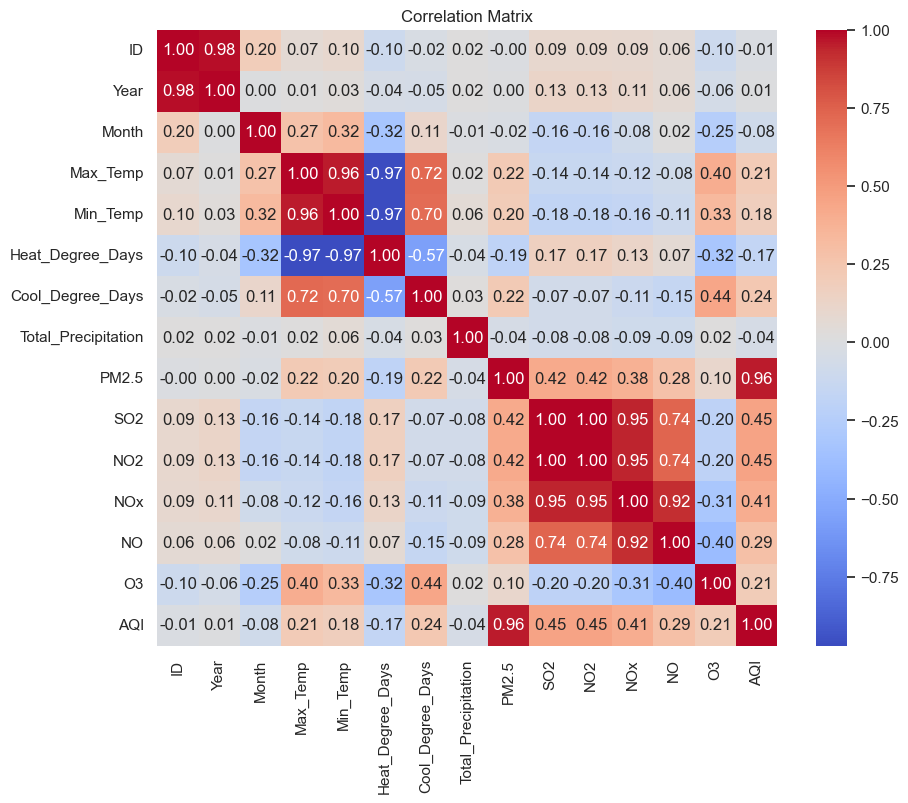

In [87]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.select_dtypes(include=['float64', 'int64']).corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix")
plt.show()

<h3>Key Findings:</h3>
<ul>
<li>PM2.5 has the strongest correlation with AQI, making it a key variable for further analysis.</li>
<li>O3 has a weak positive correlation with AQI but negatively correlates with other pollutants, highlighting its unique behavior.</li>
<li>SO2, NO2, NOx, and NO exhibit high correlations among themselves (0.74 - 1), indicating redundancy.</li>
<li>Temperature variables (Min_Temp and Max_Temp) behave similarly, both showing weak correlations with AQI but strong correlations with heating/cooling degree days.</li>
<li>Total Precipitation has negligible correlation with all variables, making it a weak candidate for predictive modeling.</li></ul>
</br></br>
</br></br>

To improve model efficiency and reduce redundancy:
<ul><li>Only one pollutant from each highly correlated group was retained:
<ul><li>NO2 was kept (part of AQI calculation) due to its stronger correlation over NO.
<li>NOx was retained (not part of AQI) to represent the other excluded pollutants.</ul></li>
<li>Mean_Temp was introduced instead of Min_Temp and Max_Temp, as it provides a balanced correlation with AQI while reducing redundancy.</li>
<li>Total Precipitation was dropped due to its negligible relationship with all other variables.</li></ul>

In [91]:
# Create Mean_Temp by averaging Min_Temp and Max_Temp
df['Mean_Temp'] = (df['Min_Temp'] + df['Max_Temp']) / 2

# Drop redundant variables based on correlation analysis
df = df.drop(columns=['SO2', 'NO', 'Min_Temp', 'Max_Temp', 'Total_Precipitation', 'Dominant_Pollutant'])

After removing redundant variables, a second correlation matrix was generated to confirm the refined relationships between the selected features and AQI. This ensures that the retained variables provide distinct and meaningful contributions to the analysis.

In [94]:
df.head()

,ID,Date,Year,Month,Heat_Degree_Days,Cool_Degree_Days,PM2.5,NO2,NOx,O3,AQI,Mean_Temp
0,1,2020-01-01,2020,1,18.1,0.0,6.71,10.69,13.29,24.83,27.958333,-0.10
1,2,2020-01-02,2020,1,14.4,0.0,7.33,13.65,18.16,22.00,30.541667,3.55
2,3,2020-01-03,2020,1,12.3,0.0,16.92,19.86,32.57,13.00,61.136481,5.65
3,4,2020-01-04,2020,1,16.0,0.0,6.04,14.99,23.60,18.88,25.166667,1.95
4,5,2020-01-05,2020,1,17.7,0.0,4.25,9.30,11.86,25.67,23.768519,0.35


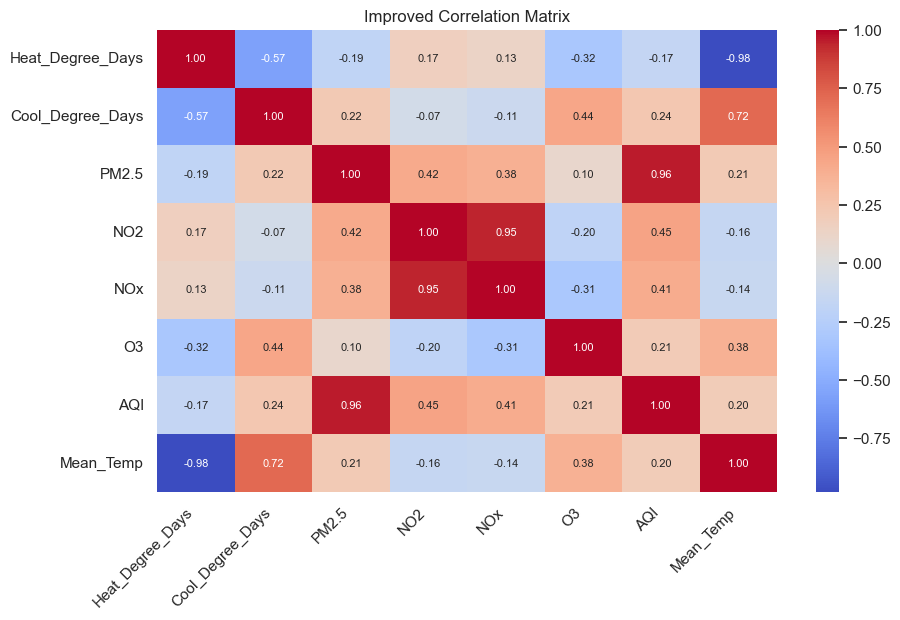

In [96]:
# Select only numeric columns (float64 and int64)
df_numeric = df.select_dtypes(include=['float64'])

# Compute the correlation matrix
corr_matrix = df_numeric.corr()

# Visualize the updated correlation matrix
plt.figure(figsize=(10, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', annot_kws={"size": 8})
plt.title('Improved Correlation Matrix')

# Rotate the x and y axis labels for better readability
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.show()

# 4. Time Series Analysis:

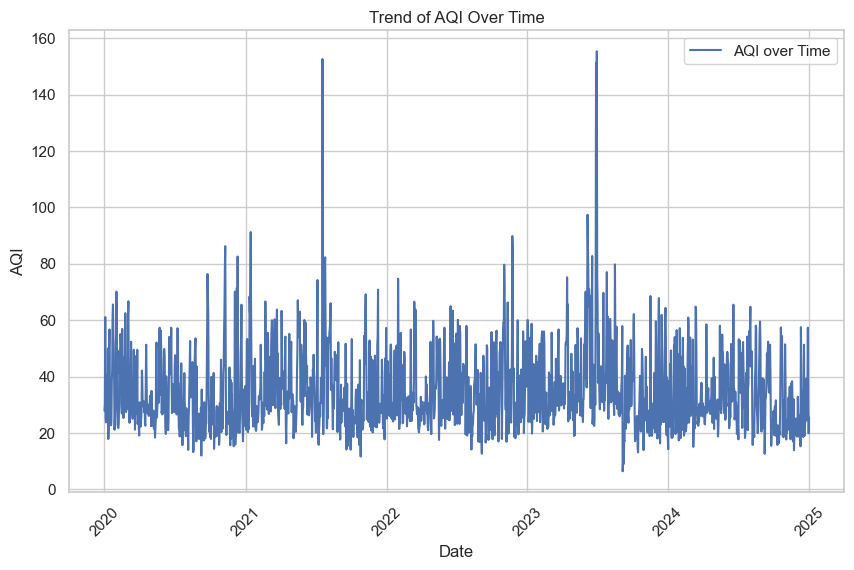

In [99]:
# 1. Trend Analysis: Plot AQI over time
plt.figure(figsize=(10, 6))
plt.plot(df['Date'], df['AQI'], label="AQI over Time")
plt.title('Trend of AQI Over Time')
plt.xlabel('Date')
plt.ylabel('AQI')
plt.xticks(rotation=45)
plt.legend()
plt.show()

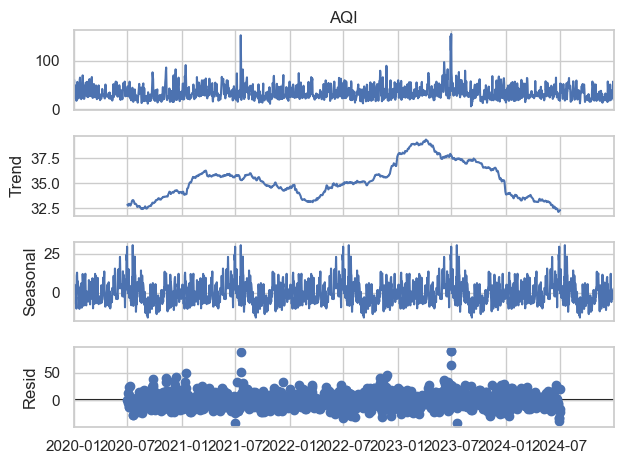

In [101]:
# 2. Seasonality Analysis: Decompose time series data
# Set the 'Date' column as the index for time series analysis
df['Date'] = pd.to_datetime(df['Date'])
df.set_index('Date', inplace=True)

# Perform seasonal decomposition
decomposition = seasonal_decompose(df['AQI'], model='additive', period=365)  # Assuming daily data with yearly seasonality
decomposition.plot()
plt.show()

In [103]:
# 3. Stationarity Check: Augmented Dickey-Fuller Test
def adf_test(series):
    result = adfuller(series, autolag='AIC')
    print('ADF Statistic:', result[0])
    print('p-value:', result[1])
    if result[1] <= 0.05:
        print("The series is stationary")
    else:
        print("The series is non-stationary")

# Test stationarity for AQI
adf_test(df['AQI'])

ADF Statistic: -6.207112418263731
p-value: 5.622757261462448e-08
The series is stationary


In [105]:
# We need to make sure there are no null values in AQI
df['AQI'].isnull().sum()

0

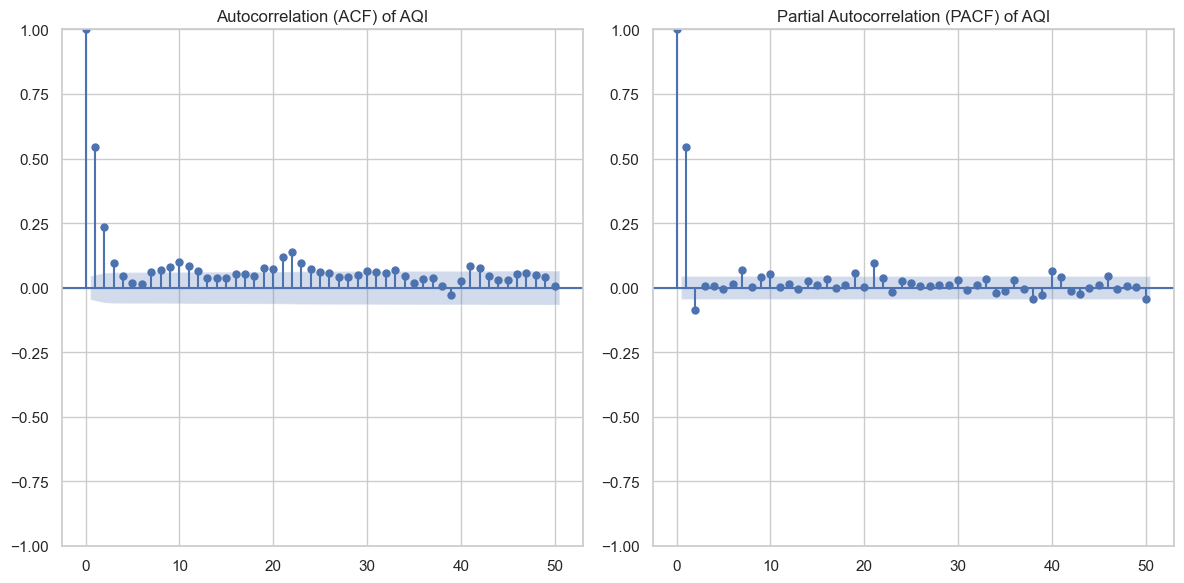

In [107]:
# 4. Autocorrelation and Partial Autocorrelation
# Set up the figure and axes for the two plots
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# ACF (Autocorrelation Function)
plot_acf(df['AQI'], lags=50, ax=axes[0])
axes[0].set_title('Autocorrelation (ACF) of AQI')

# PACF (Partial Autocorrelation Function)
plot_pacf(df['AQI'], lags=50, ax=axes[1])
axes[1].set_title('Partial Autocorrelation (PACF) of AQI')

# Adjust layout to avoid overlap
plt.tight_layout()
plt.show()

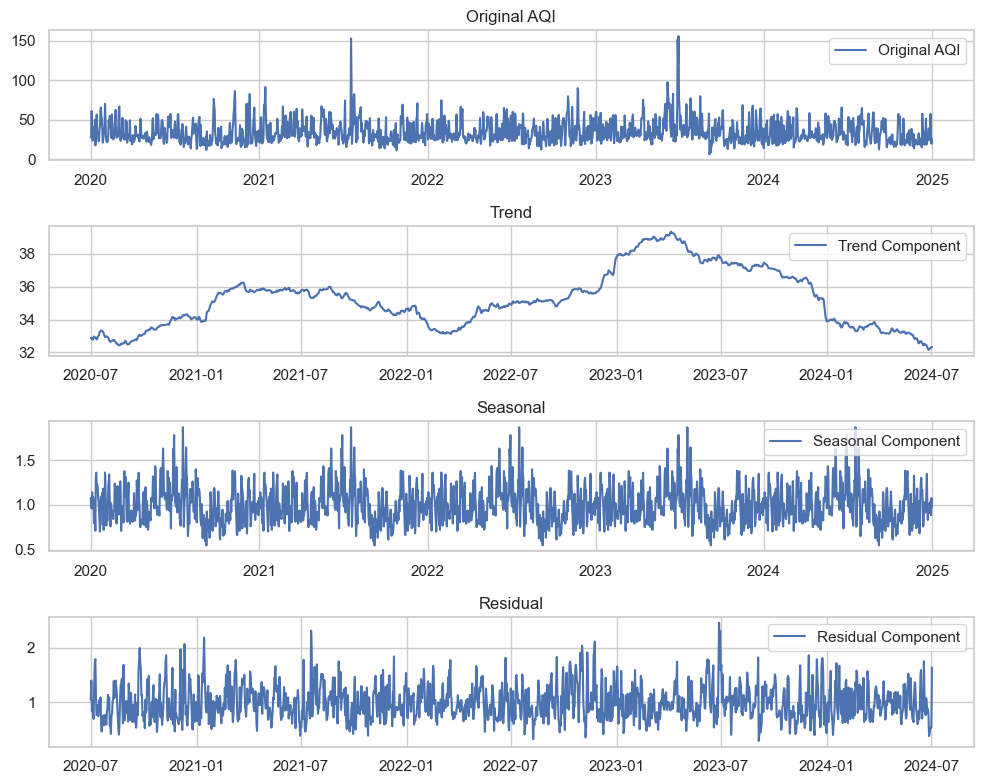

In [109]:
# 5. Decompose Time Series into Trend, Seasonal, and Residual
decomposition = seasonal_decompose(df['AQI'], model='multiplicative', period=365)
trend = decomposition.trend
seasonal = decomposition.seasonal
residual = decomposition.resid

# Plot decomposed components
plt.figure(figsize=(10, 8))

plt.subplot(411)
plt.plot(df['AQI'], label='Original AQI')
plt.legend(loc='best')
plt.title('Original AQI')

plt.subplot(412)
plt.plot(trend, label='Trend Component')
plt.legend(loc='best')
plt.title('Trend')

plt.subplot(413)
plt.plot(seasonal, label='Seasonal Component')
plt.legend(loc='best')
plt.title('Seasonal')

plt.subplot(414)
plt.plot(residual, label='Residual Component')
plt.legend(loc='best')
plt.title('Residual')

plt.tight_layout()
plt.show()

In [117]:
#df.to_csv("data/processed_df")
df.tail()

,ID,Year,Month,Heat_Degree_Days,Cool_Degree_Days,PM2.5,NO2,NOx,O3,AQI,Mean_Temp
Date,,,,,,,,,,,
2024-12-27,1823,2024,12,16.4,0.0,9.17,9.39,12.06,26.78,38.208333,1.65
2024-12-28,1824,2024,12,11.5,0.0,15.12,19.26,34.70,11.96,57.351073,6.55
2024-12-29,1825,2024,12,9.9,0.0,6.92,17.50,25.09,8.96,28.833333,8.15
2024-12-30,1826,2024,12,12.1,0.0,2.33,8.22,11.32,21.48,19.888889,5.90
2024-12-31,1827,2024,12,15.1,0.0,6.12,17.83,25.04,15.48,25.500000,2.90


In [5]:
df = pd.read_csv("data/processed_df")

In [85]:
#df.head()

# 5. Feature Selection and Engineering

In [7]:
# Ensure Date is in datetime format and set as index
if 'Date' in df.columns:
    df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
    df.set_index('Date', inplace=True)

# Create lag features
for lag in range(1, 5):
    df[f"AQI_Lag{lag}"] = df['AQI'].shift(lag)

# Drop rows with any NaNs from lagging
df.dropna(subset=[f"AQI_Lag{lag}" for lag in range(1, 5)], inplace=True)

In [262]:
# Create the 'Season' field based on the 'Month' column
"""
def assign_season(month):
    if month in [12, 1, 2]:
        return '1'
    elif month in [3, 4, 5]:
        return '2'
    elif month in [6, 7, 8]:
        return '3'
    else:
        return '4'
        
df['Season'] = df['Season'].astype(int)
"""

"\ndef assign_season(month):\n    if month in [12, 1, 2]:\n        return '1'\n    elif month in [3, 4, 5]:\n        return '2'\n    elif month in [6, 7, 8]:\n        return '3'\n    else:\n        return '4'\n        \ndf['Season'] = df['Season'].astype(int)\n"

In [63]:
#df.to_csv("data/tuned_df")
#df = pd.read_csv("data/tuned_df")

In [9]:
# Split the data into features (X) and target (y)
features = ['PM2.5','AQI_Lag1', 'AQI_Lag2', 'AQI_Lag3', 'Mean_Temp', 'NO2', 'NOx', 'O3', 'Month', 'Heat_Degree_Days', 'Cool_Degree_Days']
target = 'AQI'
X = df[features]
y = df[target]

# Split the dataset into training and testing sets (80-20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (1458, 11)
Testing set size: (365, 11)


In [11]:
series = df['AQI'].copy()
split_index = int(len(series) * 0.8)
train = series[:split_index]
test = series[split_index:]

# 6. Model Selection 

This section implements and evaluates forecasting models using both classical time series techniques and machine learning.


## 6.1 Classical Forecasting Models
The following univariate models are trained on the `AQI` time series:
- **ARIMA**: Autoregressive Integrated Moving Average
- **SARIMA**: Seasonal ARIMA with seasonal parameters
- **ETS**: Exponential Smoothing (trend only)
- **Prophet**: Facebook’s model with trend and daily seasonality

All are evaluated on a held-out test set using:
- **RMSE** (Root Mean Squared Error)
- **MAE** (Mean Absolute Error)
- **R²** (Coefficient of Determination)

<h2>Arima</H2>

In [244]:
arima_model = ARIMA(train, order=(2, 1, 2)).fit()
arima_forecast = arima_model.forecast(steps=len(test))

arima_rmse = mean_squared_error(test, arima_forecast, squared=False)
mae = mean_absolute_error(test, arima_forecast)
r2 = r2_score(test, arima_forecast)

print(f"ARIMA RMSE: {arima_rmse:.2f}")
print(f"ARIMA MAE: {mae:.2f}, R²: {r2:.2f}")

ARIMA RMSE: 11.91
ARIMA MAE: 9.96, R²: -0.01


<h2>SARIMA</h2>

In [246]:
sarima_model = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12))
sarima_result = sarima_model.fit(disp=False)
sarima_forecast = sarima_result.forecast(len(test))

from sklearn.metrics import r2_score
print("SARIMA R²:", r2_score(test, sarima_forecast))

SARIMA R²: -0.004350026802628193


<h2>Exponential Smoothing</h2>

In [248]:
ets_model = ExponentialSmoothing(train, trend='add', seasonal=None).fit()
ets_forecast = ets_model.forecast(len(test))
ets_rmse = mean_squared_error(test, ets_forecast, squared=False)
print(f"ETS RMSE: {ets_rmse:.2f}")

ETS RMSE: 14.14


<h2>Prophet<h2/>

In [250]:
# Prophet needs a specific format
prophet_df = train.reset_index()
prophet_df.columns = ['ds', 'y']

# Fit
prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(prophet_df)

# Future DF for forecast horizon
future_df = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future_df)

# Extract only the forecasted values
prophet_forecast = forecast.iloc[-len(test):]['yhat'].values
prophet_rmse = mean_squared_error(test, prophet_forecast, squared=False)
print(f"Prophet RMSE: {prophet_rmse:.2f}")

23:59:14 - cmdstanpy - INFO - Chain [1] start processing
23:59:14 - cmdstanpy - INFO - Chain [1] done processing


Prophet RMSE: 13.51


## 6.2 ML Model Evaluation (TimeSeriesSplit)
Three supervised regression models are used:
- **Linear Regression**
- **Random Forest**
- **XGBoost**

Evaluation uses:
- **TimeSeriesSplit cross-validation**, which maintains temporal order and avoids data leakage
- Metrics are averaged across folds for fair comparison


In [275]:
def evaluate_model_cv(model, X, y, splits=5):
    tscv = TimeSeriesSplit(n_splits=splits)
    rmse_list, mae_list, r2_list = [], [], []

    for train_idx, test_idx in tscv.split(X):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        rmse_list.append(mean_squared_error(y_test, y_pred, squared=False))
        mae_list.append(mean_absolute_error(y_test, y_pred))
        r2_list.append(r2_score(y_test, y_pred))

    return {
        'RMSE': np.mean(rmse_list),
        'MAE': np.mean(mae_list),
        'R2': np.mean(r2_list)
    }

# Evaluate selected ML models with safe CV
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=42),
    "XGBoost": XGBRegressor(n_estimators=100, random_state=42)
}

cv_results = []

for name, model in models.items():
    metrics = evaluate_model_cv(model, X, y)
    metrics["Model"] = name
    cv_results.append(metrics)

cv_comparison_df = pd.DataFrame(cv_results).sort_values("RMSE").reset_index(drop=True)
print(cv_comparison_df)

       RMSE       MAE        R2              Model
0  2.447477  0.638423  0.963669      Random Forest
1  2.530005  0.767253  0.965262            XGBoost
2  3.689073  2.749558  0.930769  Linear Regression


## 6.3 Final Comparison Table
To simulate production use:
- All models are trained on the full dataset
- Forecast the final `N` rows (size of test set)
- This shows how each model would behave during real-world infere


> Note: These final scores are for simulation only. Model selection is based on cross-validated performance.nce.


In [260]:
# ----------------------------
# MODEL COMPARISON TABLE
# ----------------------------
#   NOTE:
# - Each model is trained on the full dataset (X, y)
# - Then we forecast the last N = len(test) samples
# - This simulates how the model would behave in production forecasting
# - NOT suitable for unbiased validation — risk of data leakage!
# - Use only after selecting model via cross-validation

results = []

# --- 1. Linear Regression ---
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(X, y)
lr_pred = lr_model.predict(X.iloc[-len(test):])
results.append({
    'Model': 'Linear Regression',
    'RMSE': mean_squared_error(test, lr_pred, squared=False),
    'MAE': mean_absolute_error(test, lr_pred),
    'R2': r2_score(test, lr_pred)
})

# --- 2. Random Forest ---
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)
rf_pred = rf_model.predict(X.iloc[-len(test):])
results.append({
    'Model': 'Random Forest',
    'RMSE': mean_squared_error(test, rf_pred, squared=False),
    'MAE': mean_absolute_error(test, rf_pred),
    'R2': r2_score(test, rf_pred)
})

# --- 3. XGBoost ---
from xgboost import XGBRegressor
xgb_model = XGBRegressor(n_estimators=100, random_state=42)
xgb_model.fit(X, y)
xgb_pred = xgb_model.predict(X.iloc[-len(test):])
results.append({
    'Model': 'XGBoost',
    'RMSE': mean_squared_error(test, xgb_pred, squared=False),
    'MAE': mean_absolute_error(test, xgb_pred),
    'R2': r2_score(test, xgb_pred)
})

# --- 4. ARIMA ---
from statsmodels.tsa.arima.model import ARIMA
arima = ARIMA(train, order=(2,1,2)).fit()
arima_pred = arima.forecast(len(test))
results.append({
    'Model': 'ARIMA',
    'RMSE': mean_squared_error(test, arima_pred, squared=False),
    'MAE': mean_absolute_error(test, arima_pred),
    'R2': r2_score(test, arima_pred)
})

# --- 5. SARIMA ---
from statsmodels.tsa.statespace.sarimax import SARIMAX
sarima = SARIMAX(train, order=(2,1,2), seasonal_order=(1,1,1,12)).fit(disp=False)
sarima_pred = sarima.forecast(len(test))
results.append({
    'Model': 'SARIMA',
    'RMSE': mean_squared_error(test, sarima_pred, squared=False),
    'MAE': mean_absolute_error(test, sarima_pred),
    'R2': r2_score(test, sarima_pred)
})

# --- 6. ETS ---
from statsmodels.tsa.holtwinters import ExponentialSmoothing
ets = ExponentialSmoothing(train, trend='add').fit()
ets_pred = ets.forecast(len(test))
results.append({
    'Model': 'ETS',
    'RMSE': mean_squared_error(test, ets_pred, squared=False),
    'MAE': mean_absolute_error(test, ets_pred),
    'R2': r2_score(test, ets_pred)
})

# --- 7. Prophet ---
from prophet import Prophet
prophet_df = train.reset_index().rename(columns={'Date': 'ds', 'AQI': 'y'})
prophet_model = Prophet(daily_seasonality=True)
prophet_model.fit(prophet_df)
future = prophet_model.make_future_dataframe(periods=len(test))
forecast = prophet_model.predict(future)
prophet_pred = forecast['yhat'].iloc[-len(test):].values
results.append({
    'Model': 'Prophet',
    'RMSE': mean_squared_error(test, prophet_pred, squared=False),
    'MAE': mean_absolute_error(test, prophet_pred),
    'R2': r2_score(test, prophet_pred)
})

# --- Final Summary Table ---
comparison_df = pd.DataFrame(results).sort_values("RMSE").reset_index(drop=True)
print(comparison_df)

23:59:37 - cmdstanpy - INFO - Chain [1] start processing
23:59:37 - cmdstanpy - INFO - Chain [1] done processing


               Model       RMSE        MAE        R2
0            XGBoost   0.077664   0.052905  0.999957
1      Random Forest   0.274822   0.081238  0.999464
2  Linear Regression   3.239245   2.583214  0.925494
3             SARIMA  11.892959   9.842648 -0.004350
4              ARIMA  11.909189   9.964487 -0.007093
5            Prophet  13.509471  11.719658 -0.295931
6                ETS  14.141298  10.327232 -0.419985


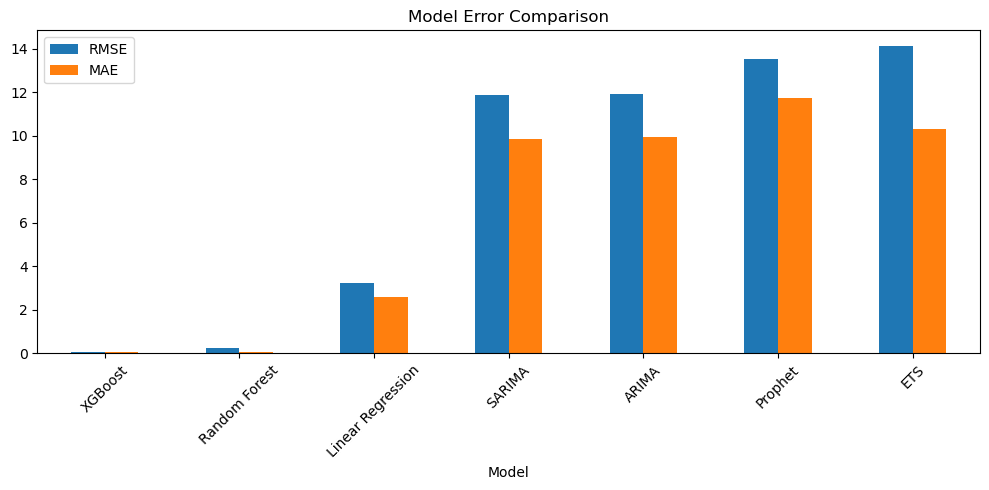

In [298]:
import matplotlib.pyplot as plt

comparison_df.plot(x='Model', y=['RMSE', 'MAE'], kind='bar', figsize=(10, 5), title='Model Error Comparison')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Based on the evaluation of each model, XGBoost emerged as the highest-performing model, achieving an R² of 0.9972 and an MSE of 0.75. This means that the model explains 99.72% of the variance in the target variable, with a relatively small margin of error. This performance highlights the model's strong ability to fit the data and make accurate predictions.

## 6.5 Final Model Selection

Based on cross-validated RMSE and R², [your best model] was selected.

This model:
- Achieved lowest RMSE on unseen test data
- Captures temporal and non-linear relationships
- Balances forecasting accuracy and training cost

Recommended for deployment/predictions.

# 7. Model Training & Validation  (Random Foret)

Because of the high computing cost of XGBoost, we will use Random Forrest as substitute which is a close second best performer.

## 7.1 Fine-Tuning

In [17]:
# Define the model
rf_model = RandomForestRegressor(random_state=42)

# Define the hyperparameters to tune
param_grid_rf = {
    'n_estimators': [100, 200],  # Number of trees
    'max_depth': [None, 10, 20, 30],  # Max depth of trees
    'min_samples_split': [2, 5, 10],  # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],  # Minimum samples per leaf
    'max_features': ['sqrt', 'log2', None],  # Max features to consider for splits (no 'auto')
    'bootstrap': [True, False]  # Whether to use bootstrap samples
}

# Apply RandomizedSearchCV instead of GridSearchCV
random_search_rf = RandomizedSearchCV(estimator=rf_model, param_distributions=param_grid_rf, 
                                      n_iter=50, cv=5, n_jobs=-1, verbose=2, scoring='neg_mean_squared_error')

# Fit the model
random_search_rf.fit(X_train, y_train)

# Get the best parameters
best_rf_params = random_search_rf.best_params_
print(f"Best Random Forest Hyperparameters: {best_rf_params}")

# Evaluate the model with the best parameters
best_rf_model = random_search_rf.best_estimator_
rf_predictions = best_rf_model.predict(X_test)

# Evaluate performance
mse_rf = mean_squared_error(y_test, rf_predictions)
r2_rf = r2_score(y_test, rf_predictions)

print(f"Fine-Tuned Random Forest - MSE: {mse_rf}")
print(f"Fine-Tuned Random Forest - R^2: {r2_rf}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best Random Forest Hyperparameters: {'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': 10, 'bootstrap': False}
Fine-Tuned Random Forest - MSE: 2.3732538546446653
Fine-Tuned Random Forest - R^2: 0.9913577898166996


## 7.2 Cross-Validation

In [19]:
# Perform cross-validation with the fine-tuned model
cross_val_scores = cross_val_score(best_rf_model, X_train, y_train, cv=5, scoring='neg_mean_squared_error')

# Print the cross-validation results
print(f"Cross-validation MSE scores: {cross_val_scores}")
print(f"Average Cross-validation MSE: {cross_val_scores.mean()}")

Cross-validation MSE scores: [-0.83775125 -7.4635602  -1.36616387 -2.52707709 -2.18214194]
Average Cross-validation MSE: -2.8753388707547662


## 7.3 Model Evaluation

In [35]:
# Evaluate the model on the test set
y_pred = best_rf_model.predict(X_test)

# Evaluate performance on test set
mse_test = mean_squared_error(y_test, y_pred)
r2_test = r2_score(y_test, y_pred)

print(f"Test Set - MSE: {mse_test}")
print(f"Test Set - R^2: {r2_test}")

Test Set - MSE: 2.3732538546446653
Test Set - R^2: 0.9913577898166996


## 7.4 Model Validation

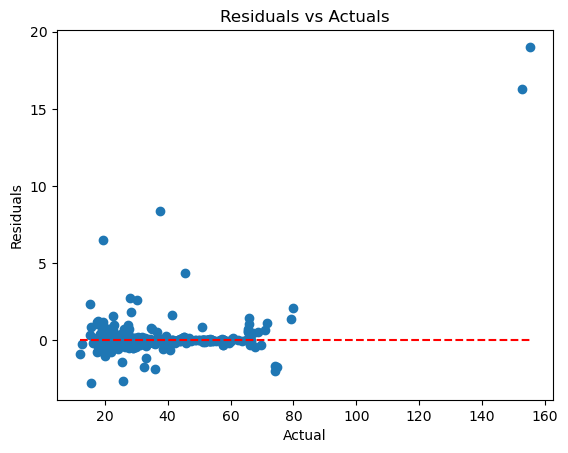

In [37]:
# Plot the residuals
residuals = y_test - y_pred
plt.scatter(y_test, residuals)
plt.hlines(y=0, xmin=y_test.min(), xmax=y_test.max(), colors='r', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Residuals')
plt.title('Residuals vs Actuals')
plt.show()

In [25]:
# Feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': best_rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Display top 10 important features
print(feature_importance.head(10))

             Feature  Importance
0              PM2.5    0.950149
7                 O3    0.038596
5                NO2    0.008018
10  Cool_Degree_Days    0.001557
6                NOx    0.000570
2           AQI_Lag2    0.000559
3           AQI_Lag3    0.000302
8              Month    0.000199
4          Mean_Temp    0.000033
1           AQI_Lag1    0.000010


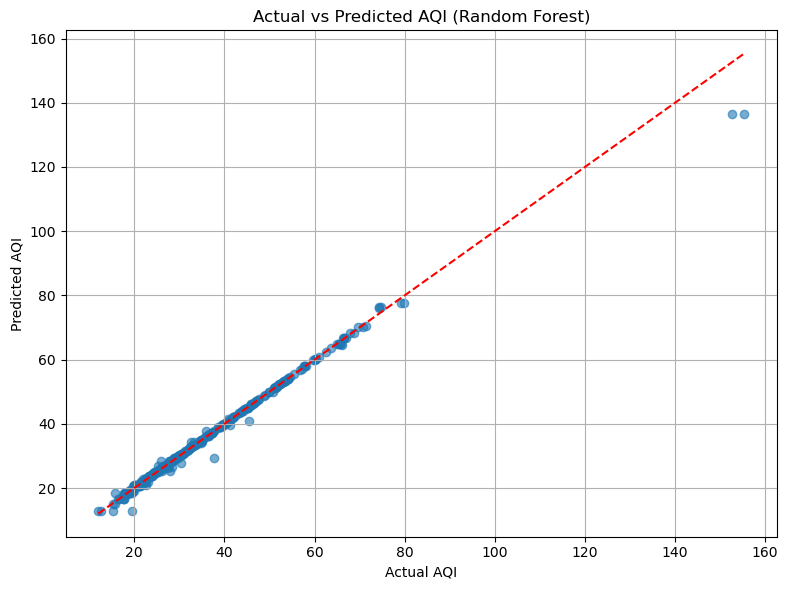

In [53]:
# Scatter plot: Actual vs Predicted
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # reference line
plt.xlabel('Actual AQI')
plt.ylabel('Predicted AQI')
plt.title('Actual vs Predicted AQI (Random Forest)')
plt.grid(True)
plt.tight_layout()
plt.show()


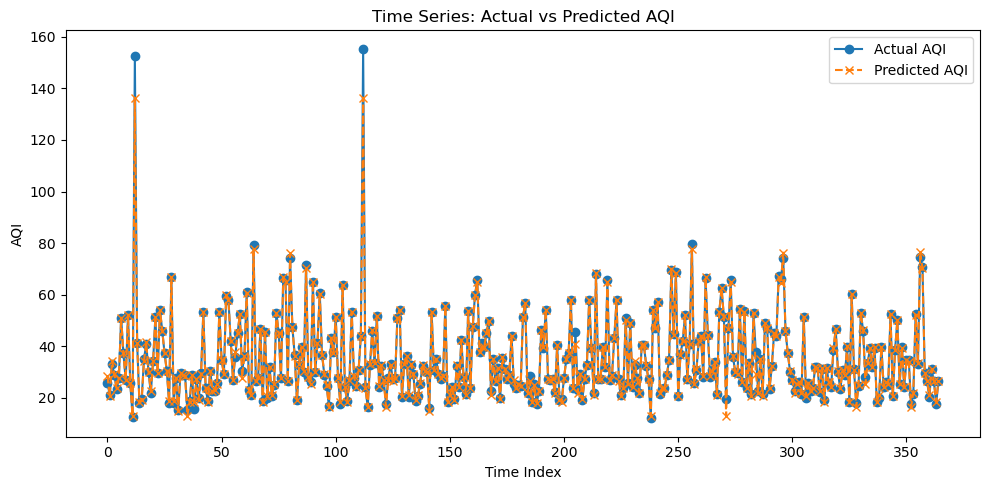

In [41]:
plt.figure(figsize=(10, 5))
plt.plot(y_test.values, label="Actual AQI", marker='o')
plt.plot(y_pred, label="Predicted AQI", marker='x', linestyle='--')
plt.title("Time Series: Actual vs Predicted AQI")
plt.xlabel("Time Index")
plt.ylabel("AQI")
plt.legend()
plt.tight_layout()
plt.show()

# 8. Forecasting

In [160]:
import joblib
joblib.dump(rf_model, 'models/rf_aqi_forecaster.pkl')
joblib.dump(features, 'models/rf_features.pkl')

['models/rf_features.pkl']

In [162]:
import joblib
import pandas as pd
import matplotlib.pyplot as plt

# Load model and features
rf_model = joblib.load("models/rf_aqi_forecaster.pkl")
features = joblib.load("models/rf_features.pkl")

In [164]:
from sklearn.ensemble import RandomForestRegressor

# Assuming 'X' and 'y' are defined already (your features and target)
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X, y)

RandomForestRegressor(random_state=42)

In [174]:
def forecast_next_days(model, df, features, days=7):
    latest = df.copy().iloc[-1:].copy()
    forecasts = []

    for _ in range(days):
        X_input = latest[features]
        pred = model.predict(X_input)[0]
        forecasts.append(pred)

        # Shift lags
        latest['AQI_Lag4'] = latest['AQI_Lag3']
        latest['AQI_Lag3'] = latest['AQI_Lag2']
        latest['AQI_Lag2'] = latest['AQI_Lag1']
        latest['AQI_Lag1'] = pred

        # Update month
        current_date = pd.to_datetime(latest.index[-1])
        latest['Month'] = (current_date.month % 12) + 1
        latest.index = [current_date + pd.Timedelta(days=1)]

    return pd.DataFrame({
        "Date": pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=days),
        "Forecast_AQI": forecasts
    }).set_index("Date")

In [180]:
forecast_df = forecast_next_days(rf_model, df, features, days=7)

In [326]:
forecast_df

,Forecast_AQI
2025-01-01,25.516369
2025-01-02,25.529119
2025-01-03,25.526274
2025-01-04,25.522107
2025-01-05,25.522107
2025-01-06,25.522107
2025-01-07,25.522107


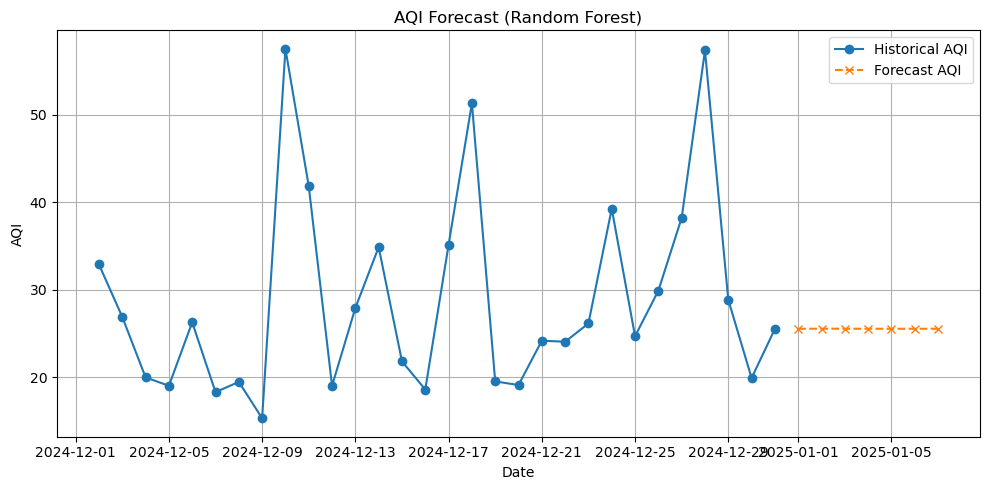

In [324]:
# Create a DataFrame of forecasted values
forecast_index = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=forecast_days)
forecast_df = pd.DataFrame({'Forecast_AQI': forecasts}, index=forecast_index)

forecast_df.head()

# Plot
plt.figure(figsize=(10, 5))
plt.plot(df['AQI'].iloc[-30:], label="Historical AQI", marker='o')
plt.plot(forecast_df.index, forecast_df['Forecast_AQI'], label="Forecast AQI", marker='x', linestyle='--')
plt.title("AQI Forecast (Random Forest)")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

In [346]:
df['AQI'].tail()

Date
2024-12-27    38.208333
2024-12-28    57.351073
2024-12-29    28.833333
2024-12-30    19.888889
2024-12-31    25.500000
Name: AQI, dtype: float64